- BingHive is a streaming platform like Netflix, which allows its users to watch series and movies.

- The OTT market is competitive and BingHive is competing against a lot of established players like Netflix, prime, Hotstar, etc. Their tech team keeps making new releases to the app and they rolled out a new update to the "Search" feature of the app.

- The users rely on the "Search" feature heavily to discover what they can watch on the platform.
 
 - It's October 16, 2019, today. In mid-August, BingHive released an update after which the app's ratings across all platforms started to drop.  The rating for the last update alone fluctuated between 1 and 2.

In [1]:
import pandas as pd 
import numpy as np 

In [2]:
user = pd.read_csv(r"C:\Documents\Machine Learning\users_activity_log.csv")
user.head(5)

,user_id,occurred_at,event_name,os,os_version,device_id
0,4436047,04-10-2022 15:18,watchlists,android,12,146
1,905476,31-08-2022 15:19,home,windows,10,511
2,5038318,10-10-2022 08:33,watchlists,windows,10,512
3,489996,09-09-2022 08:54,library,windows,10,511
4,3065600,03-09-2022 17:39,settings,windows,10,511


In [3]:
device = pd.read_csv(r"C:\Documents\Machine Learning\device_details.csv")
device.head(5)

,device_id,name,screen_size,os_version,ram,battery,chipset
0,408,Xiaomi Mi 10T Lite 5G,"6.67""",Android 10,6 GB RAM,4820 mAh Li-Po,Qualcomm SM7225 Snapdragon 750G 5G (8 nm)
1,229,Oppo Find X2 Neo,"6.5""",Android 10,12 GB RAM,4025 mAh Li-Po,Qualcomm SM7250 Snapdragon 765G 5G (7 nm)
2,452,Infinix Zero 5,"5.98""",Android 7.0,6 GB RAM,4350 mAh Li-Ion,Qualcomm SDM730 Snapdragon 730 (8 nm)
3,371,Xiaomi Black Shark 4S,"6.67""",Android 11,8/12 GB RAM,4500 mAh Li-Po,Qualcomm SM8250-AC Snapdragon 870 5G (7 nm)
4,59,Infinix Zero 5G,"6.78""",Android 11,8 GB RAM,5000 mAh Li-Po,Qualcomm SM8150 Snapdragon 855+ (7 nm)


In [4]:
print("shape of user: ",user.shape)
print("shape of device: ",device.shape)

shape of user:  (368714, 6)
shape of device:  (453, 7)


In [5]:
df = pd.merge(user, device, on='device_id', how='inner')

In [6]:
df.sample(6)

,user_id,occurred_at,event_name,os,os_version_x,device_id,name,screen_size,os_version_y,ram,battery,chipset
186572,5805761,18-09-2022 06:33,home,android,12,361,Samsung Galaxy M53,"6.7""",Android 12,6/8 GB RAM,5000 mAh Li-Ion,Mediatek MT6877 Dimensity 900 (6 nm)
109408,1169299,19-09-2022 16:21,home,ios,13,506,iPhone 11 Pro Max,"6.1""",iOS 13,4 GB RAM,3110 mAh,Apple A13 Bionic
28466,6913721,16-09-2022 10:48,home,windows,10,511,Desktop,NaN,Windows 10,NaN,NaN,Intel/AMD
213764,7604921,23-09-2022 16:27,home,ios,11,507,iPhone X,NaN,iOS 11,3 GB RAM,NaN,Apple A11 Bionic
223215,4401596,09-09-2022 08:58,login,ios,12,508,iPhone XR,NaN,iOS 12,3 GB RAM,NaN,Apple A12 Bionic
211435,198245,09-09-2022 10:39,watchlists,ios,11,507,iPhone X,NaN,iOS 11,3 GB RAM,NaN,Apple A11 Bionic


In [8]:
df['event_name'].value_counts()

home                   94065
watchlists             59248
library                55936
run_query              54541
login                  38610
settings               33105
autocomplete_engine    17820
query_result_0          5617
query_result_2          1499
query_result_1          1413
query_result_4          1264
query_result_3          1134
query_result_5           968
query_result_6           805
query_result_9           784
query_result_7           709
query_result_8           690
query_result_10          506
Name: event_name, dtype: int64

In [11]:
df['occurred_at'].value_counts().sort_values()

03-10-2022 07:36      1
14-10-2022 06:34      1
08-10-2022 02:12      1
02-10-2022 08:16      1
09-10-2022 10:50      1
                   ... 
19-09-2022 08:50    651
12-09-2022 08:50    681
11-09-2022 08:51    702
18-09-2022 08:50    770
11-09-2022 08:50    938
Name: occurred_at, Length: 44486, dtype: int64

In [15]:
filtered_df = df[df['event_name'].isin(['run_query', 'autocomplete_engine',
'query_result_0',          
'query_result_2',         
'query_result_1',         
'query_result_4',         
'query_result_3',          
'query_result_5',          
'query_result_6',           
'query_result_9',           
'query_result_7',           
'query_result_8',          'query_result_10' ])]
filtered_df

,user_id,occurred_at,event_name,os,os_version_x,device_id,name,screen_size,os_version_y,ram,battery,chipset
9,3514630,17-09-2022 08:50,autocomplete_engine,android,12,146,OnePlus 10 Pro,"6.7""",Android 12,8/12 GB RAM,5000 mAh Li-Po,Qualcomm SM8450 Snapdragon 8 Gen 1 (4 nm)
16,5981239,30-09-2022 11:00,run_query,android,12,146,OnePlus 10 Pro,"6.7""",Android 12,8/12 GB RAM,5000 mAh Li-Po,Qualcomm SM8450 Snapdragon 8 Gen 1 (4 nm)
17,9416881,07-09-2022 08:50,run_query,android,12,146,OnePlus 10 Pro,"6.7""",Android 12,8/12 GB RAM,5000 mAh Li-Po,Qualcomm SM8450 Snapdragon 8 Gen 1 (4 nm)
27,3514630,17-09-2022 08:52,autocomplete_engine,android,12,146,OnePlus 10 Pro,"6.7""",Android 12,8/12 GB RAM,5000 mAh Li-Po,Qualcomm SM8450 Snapdragon 8 Gen 1 (4 nm)
37,5981239,30-09-2022 11:03,run_query,android,12,146,OnePlus 10 Pro,"6.7""",Android 12,8/12 GB RAM,5000 mAh Li-Po,Qualcomm SM8450 Snapdragon 8 Gen 1 (4 nm)
...,...,...,...,...,...,...,...,...,...,...,...,...
368675,4511233,25-08-2022 09:33,run_query,android,11,468,vivo Y73,"6.44""",Android 11,8 GB RAM,4000 mAh Li-Po,Mediatek Helio G95 (12 nm)
368679,4511233,25-08-2022 09:33,run_query,android,11,468,vivo Y73,"6.44""",Android 11,8 GB RAM,4000 mAh Li-Po,Mediatek Helio G95 (12 nm)
368680,4511233,25-08-2022 09:35,query_result_3,android,11,468,vivo Y73,"6.44""",Android 11,8 GB RAM,4000 mAh Li-Po,Mediatek Helio G95 (12 nm)
368683,4511233,25-08-2022 09:35,query_result_2,android,11,468,vivo Y73,"6.44""",Android 11,8 GB RAM,4000 mAh Li-Po,Mediatek Helio G95 (12 nm)


In [18]:
fdf = filtered_df[['occurred_at', 'event_name']].value_counts()
fdf

occurred_at       event_name         
11-09-2022 08:50  autocomplete_engine    131
18-09-2022 08:50  autocomplete_engine     93
11-09-2022 08:51  run_query               90
11-09-2022 08:50  run_query               86
11-09-2022 07:39  run_query               85
                                        ... 
12-09-2022 11:46  run_query                1
                  autocomplete_engine      1
12-09-2022 11:45  autocomplete_engine      1
12-09-2022 11:41  autocomplete_engine      1
31-08-2022 23:21  run_query                1
Length: 37280, dtype: int64

In [19]:
import matplotlib.pyplot as plt

<AxesSubplot:>

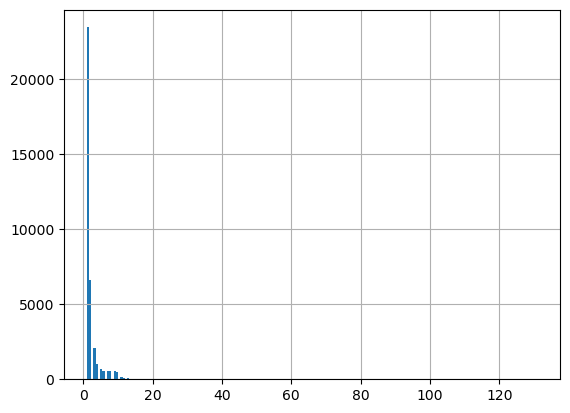

In [25]:
fdf.hist(bins=)

In [27]:
fdf = filtered_df[['occurred_at', 'event_name']].value_counts().head(10)
fdf

occurred_at       event_name         
11-09-2022 08:50  autocomplete_engine    131
18-09-2022 08:50  autocomplete_engine     93
11-09-2022 08:51  run_query               90
11-09-2022 08:50  run_query               86
11-09-2022 07:39  run_query               85
12-09-2022 08:50  autocomplete_engine     85
19-09-2022 08:50  autocomplete_engine     83
03-09-2022 08:51  run_query               83
19-09-2022 08:50  run_query               80
20-09-2022 08:52  run_query               77
dtype: int64

<AxesSubplot:>

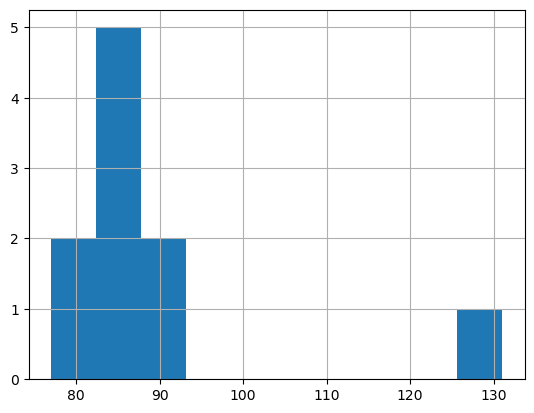

In [28]:
fdf.hist()